# Corbel Shear Capacity ML Framework

**Paper:** *Source-Study-Aware Validation and Explainable Machine Learning for Reliable Shear Capacity Assessment of Steel-Fiber-Reinforced Concrete Corbels*

 hyperparameter selection and feature standardization are performed **exclusively within the training portion of every outer evaluation**, using a nested, group-aware inner cross-validation — never on the complete dataset. This means:
- For the **predefined source-study hold-out** (Table 7), hyperparameters are selected using only the five training-source studies.
- For **each of the 27 exhaustive source-study partitions** (Table 8), hyperparameters are re-selected independently within that partition's own training studies — so different partitions can select different hyperparameters.

Run all cells top to bottom (Runtime → Run all). The exhaustive nested search (Table 8) is the slowest step, taking roughly 8–15 minutes depending on the runtime.


In [1]:
# 1) Setup — install/import packages
!pip -q install xgboost shap statsmodels openpyxl 2>/dev/null || \
 pip -q install --break-system-packages xgboost shap statsmodels openpyxl

import pandas as pd, numpy as np, itertools, warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import KFold, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.utils import resample
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from xgboost import XGBRegressor
import shap
import matplotlib.pyplot as plt
import seaborn as sns

# Match the manuscript's serif typesetting (Times-compatible) in all figures
plt.rcParams['font.family'] = 'Liberation Serif'
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.size'] = 12
plt.rcParams['savefig.dpi'] = 300

pd.set_option('display.width', 120)
np.set_printoptions(suppress=True)


In [2]:
# 1b) Reproducibility — report exact library versions used in this run
# (Reviewer 1, Comment 2 / Reviewer 2, Comment 10: software and library versions)
import sklearn, xgboost as _xgb_mod, shap as _shap_mod, statsmodels as _sm_mod, platform
print(f"python       {platform.python_version()}")
print(f"pandas       {pd.__version__}")
print(f"numpy        {np.__version__}")
print(f"scikit-learn {sklearn.__version__}")
print(f"xgboost      {_xgb_mod.__version__}")
print(f"shap         {_shap_mod.__version__}")
print(f"statsmodels  {_sm_mod.__version__}")
print("\n>>> Copy these exact version numbers into Section 2.4.1 of the manuscript <<<")

python       3.13.15
pandas       2.2.3
numpy        2.1.3
scikit-learn 1.6.1
xgboost      3.4.1
shap         0.52.0
statsmodels  0.14.6

>>> Copy these exact version numbers into Section 2.4.1 of the manuscript <<<


In [3]:
# 2) Upload the dataset
# In Colab this opens a file-picker. If you're running locally, comment this out
# and set DATA_PATH to the file's path directly.
try:
    from google.colab import files
    uploaded = files.upload()
    DATA_PATH = list(uploaded.keys())[0]
except ImportError:
    DATA_PATH = "Corbel_Veri_Seti_En_Son_Bu.xlsx"   # local fallback

print("Using file:", DATA_PATH)


Saving Corbel_Veri_Seti_En_Son_Bu.xlsx to Corbel_Veri_Seti_En_Son_Bu.xlsx
Using file: Corbel_Veri_Seti_En_Son_Bu.xlsx


In [4]:
# 3) Load data and reconstruct the 7 source-study groups
# The workbook stores rows in the same order as Appendix Table A1 of the paper,
# grouped by source study. Group sizes below sum to 108 and were verified against
# the specimen designations and value ranges printed in Table A1.
df = pd.read_excel(DATA_PATH)
df = df.rename(columns={'ad': 'a_d', 'p': 'rho'})
features = ['a_d', 'b', 'rho', 'fy', 'fc', 'ff', 'vf']
X = df[features].values
y = df['vexp'].values
n_total = len(df)

group_sizes = [5, 6, 6, 17, 22, 28, 24]
group_names = ['Fattuhi (1987)', 'Fattuhi & Hughes (1989a)', 'Fattuhi & Hughes (1989b)',
                'Fattuhi (1990a)', 'Fattuhi (1990b)', 'Fattuhi (1994)', 'Gulsan (2015)']
groups = np.concatenate([[i] * s for i, s in enumerate(group_sizes)])
assert len(groups) == n_total == 108, "Row count / group size mismatch — check the uploaded file"

print(f"N = {n_total} specimens across {len(group_sizes)} source studies")
for name, size in zip(group_names, group_sizes):
    print(f"  {name:28s} n={size}")


N = 108 specimens across 7 source studies
  Fattuhi (1987)               n=5
  Fattuhi & Hughes (1989a)     n=6
  Fattuhi & Hughes (1989b)     n=6
  Fattuhi (1990a)              n=17
  Fattuhi (1990b)              n=22
  Fattuhi (1994)               n=28
  Gulsan (2015)                n=24


In [5]:
# 4) TABLE 2 — Preprocessing summary
n_missing = int(df[features + ['vexp']].isna().sum().sum())
n_dupes = int(df.duplicated().sum())
z = (X - X.mean(axis=0)) / X.std(axis=0)
n_outliers = int((np.abs(z) > 3).any(axis=1).sum())

table2 = pd.DataFrame({
    "Description": ["Number of original specimens", "Number of missing cells",
                     "Number of duplicate rows", "Number of rows with |Z-score| > 3",
                     "Number of specimens removed", "Final number of specimens used"],
    "Value": [n_total, n_missing, n_dupes, n_outliers, 0, n_total - 0]
})
print("TABLE 2 (paper): 108 / 0 / 0 / 0 / 0 / 108")
print("TABLE 2 (reproduced):")
table2


TABLE 2 (paper): 108 / 0 / 0 / 0 / 0 / 108
TABLE 2 (reproduced):


,Description,Value
0,Number of original specimens,108
1,Number of missing cells,0
2,Number of duplicate rows,0
3,Number of rows with |Z-score| > 3,0
4,Number of specimens removed,0
5,Final number of specimens used,108


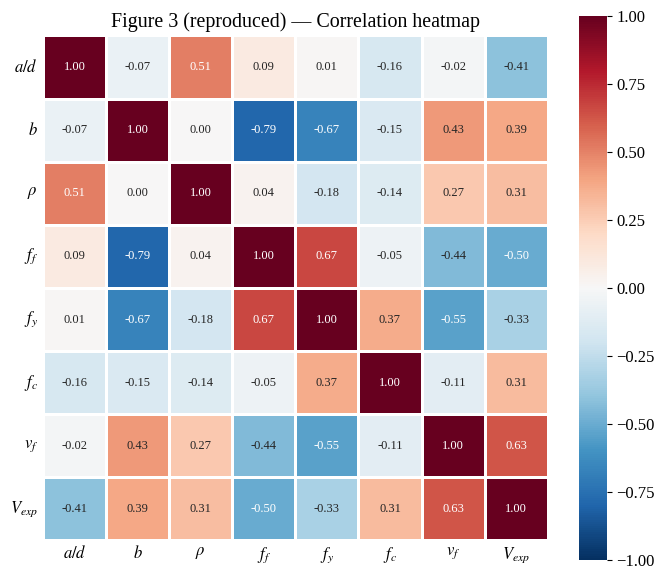

Paper:       Vf=0.63  ff=-0.50  a/d=-0.41  rho=0.31  ff-fy=0.67
Reproduced:  Vf=0.63  ff=-0.50  a/d=-0.41  rho=0.31  ff-fy=0.67


In [6]:
# 5) FIGURE 3 — Correlation heatmap + Pearson r with Vexp (styled to match published Figure 3)
import seaborn as sns

corr = pd.DataFrame(X, columns=features).assign(Vexp=y).corr()
plot_order = ['a_d', 'b', 'rho', 'ff', 'fy', 'fc', 'vf']
corr_plot = corr.reindex(index=plot_order + ['Vexp'], columns=plot_order + ['Vexp'])
pretty = {'a_d': r'$a/d$', 'b': r'$b$', 'rho': r'$\rho$', 'ff': r'$f_f$',
          'fy': r'$f_y$', 'fc': r'$f_c$', 'vf': r'$v_f$', 'Vexp': r'$V_{exp}$'}
labels = [pretty[c] for c in corr_plot.columns]

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_plot, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1,
            square=True, linewidths=1, linecolor='white',
            cbar_kws={'ticks': np.arange(-1, 1.01, 0.25)}, ax=ax,
            xticklabels=labels, yticklabels=labels, annot_kws={'fontsize': 9})
ax.tick_params(length=0)
plt.yticks(rotation=0)
plt.title('Figure 3 (reproduced) — Correlation heatmap')
plt.tight_layout()
plt.show()

print("Paper:       Vf=0.63  ff=-0.50  a/d=-0.41  rho=0.31  ff-fy=0.67")
r = corr['Vexp']
print(f"Reproduced:  Vf={r['vf']:.2f}  ff={r['ff']:.2f}  a/d={r['a_d']:.2f}  "
      f"rho={r['rho']:.2f}  ff-fy={corr.loc['ff','fy']:.2f}")

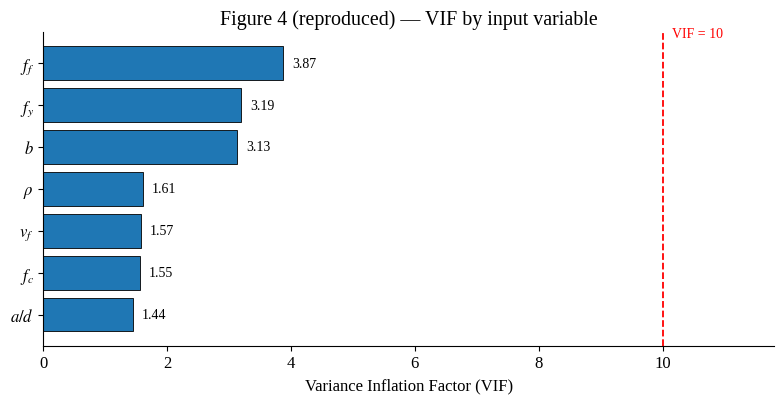

Paper:       a/d=1.45 fc=1.55 vf=1.57 rho=1.61 b=3.13 fy=3.19 ff=3.87
Reproduced:  {'a_d': 1.44, 'fc': 1.55, 'vf': 1.57, 'rho': 1.61, 'b': 3.13, 'fy': 3.19, 'ff': 3.87}


In [7]:
# 6) FIGURE 4 — Variance Inflation Factor (VIF) (styled to match published Figure 4)
Xc = sm.add_constant(pd.DataFrame(X, columns=features))
vif = pd.Series([variance_inflation_factor(Xc.values, i) for i in range(1, Xc.shape[1])],
                 index=features).sort_values()
pretty = {'a_d': r'$a/d$', 'b': r'$b$', 'rho': r'$\rho$', 'ff': r'$f_f$',
          'fy': r'$f_y$', 'fc': r'$f_c$', 'vf': r'$v_f$'}

fig, ax = plt.subplots(figsize=(8, 4.2))
bars = ax.barh([pretty[f] for f in vif.index], vif.values, color='#1f77b4',
                edgecolor='black', linewidth=0.6)
for b, v in zip(bars, vif.values):
    ax.text(v + 0.15, b.get_y() + b.get_height()/2, f'{v:.2f}', va='center', fontsize=10)
ax.axvline(10, color='red', linestyle='--', linewidth=1.3)
ax.text(10.15, len(vif) - 0.3, 'VIF = 10', color='red', fontsize=10, va='center')
ax.set_xlabel('Variance Inflation Factor (VIF)')
ax.set_xlim(0, max(11.8, vif.max() * 1.15))
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.title('Figure 4 (reproduced) — VIF by input variable')
plt.tight_layout()
plt.show()

print("Paper:       a/d=1.45 fc=1.55 vf=1.57 rho=1.61 b=3.13 fy=3.19 ff=3.87")
print("Reproduced: ", vif.round(2).to_dict())

## 7) Nested hyperparameter search — core function

This function performs the inner, group-aware hyperparameter search used throughout the rest of the notebook. It is given **only the outer training data** (never the outer test data) and returns the best Ridge alpha and XGBoost configuration found via `GroupKFold` on that training data alone. The number of inner folds is capped at 5 but reduced automatically when fewer training-source studies are available (as happens for several of the 27 exhaustive partitions).


In [8]:
import itertools

ALPHAS = [0.001, 0.01, 0.1, 0.5, 1, 5, 10, 50, 100]
PARAM_GRID = dict(n_estimators=[200, 400, 600], max_depth=[2, 3, 4],
                   learning_rate=[0.03, 0.05, 0.1], subsample=[0.8, 1.0],
                   colsample_bytree=[0.8, 1.0], reg_lambda=[0.5, 1.0])
XGB_KEYS = list(PARAM_GRID.keys())
XGB_COMBOS = list(itertools.product(*PARAM_GRID.values()))
print(f"XGBoost search grid: {len(XGB_COMBOS)} combinations (6 hyperparameters); "
      f"gamma=0.3 is fixed a priori and not part of this grid.")

def inner_tune(Xtr, ytr, groups_tr):
    """Group-aware inner search using ONLY the outer-training data provided.
    Returns (best_ridge_alpha, best_xgb_params_dict)."""
    uniq = np.unique(groups_tr)
    n_splits = min(5, len(uniq))
    if n_splits < 2:
        return 10, dict(n_estimators=600, max_depth=2, learning_rate=0.05,
                         subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0)
    gkf_inner = GroupKFold(n_splits=n_splits)

    best_alpha, best_alpha_score = 10, -np.inf
    for a in ALPHAS:
        scores = []
        for tr, te in gkf_inner.split(Xtr, ytr, groups_tr):
            sc = StandardScaler().fit(Xtr[tr])
            m = Ridge(alpha=a).fit(sc.transform(Xtr[tr]), ytr[tr])
            scores.append(r2_score(ytr[te], m.predict(sc.transform(Xtr[te]))))
        mean_s = np.mean(scores)
        if mean_s > best_alpha_score:
            best_alpha_score, best_alpha = mean_s, a

    best_xgb, best_xgb_score = None, -np.inf
    for vals in XGB_COMBOS:
        params = dict(zip(XGB_KEYS, vals))
        scores = []
        for tr, te in gkf_inner.split(Xtr, ytr, groups_tr):
            m = XGBRegressor(**params, gamma=0.3, objective='reg:squarederror',
                              random_state=42, verbosity=0)
            m.fit(Xtr[tr], ytr[tr])
            scores.append(r2_score(ytr[te], m.predict(Xtr[te])))
        mean_s = np.mean(scores)
        if mean_s > best_xgb_score:
            best_xgb_score, best_xgb = mean_s, params

    return best_alpha, best_xgb


XGBoost search grid: 216 combinations (6 hyperparameters); gamma=0.3 is fixed a priori and not part of this grid.


In [9]:
# 8) Reference split (predefined source-study hold-out) and TABLE 3
# Test set = Fattuhi (1987) [group 0] + Fattuhi (1990a) [group 3] -> 22/108 = 20.4%
# This split designates two complete source studies as a fixed test set (not a random
# group-splitting function); the 20.4% test share falls within the 15-35% range used
# for the exhaustive partitions below.
test_mask = np.isin(groups, [0, 3])
train_mask = ~test_mask
print(f"Reference split: test n={test_mask.sum()} ({100*test_mask.sum()/n_total:.1f}%), "
      f"train n={train_mask.sum()}")
for name, idx in [('Fattuhi (1987)', 0), ('Fattuhi (1990a)', 3)]:
    print(f"  TEST  <- {group_names[idx]}: n={group_sizes[idx]}")
for i, name in enumerate(group_names):
    if i not in (0, 3):
        print(f"  TRAIN <- {name}: n={group_sizes[i]}")

# TABLE 3 — inner search using ONLY the 5 training-source studies
RIDGE_ALPHA, XGB_PARAMS_BASE = inner_tune(X[train_mask], y[train_mask], groups[train_mask])
XGB_PARAMS = dict(XGB_PARAMS_BASE, gamma=0.3, objective='reg:squarederror',
                   random_state=42, verbosity=0)
print(f"\nTable 3 (predefined hold-out reference config):")
print(f"  Ridge alpha = {RIDGE_ALPHA}")
print(f"  XGBoost params = {XGB_PARAMS_BASE}")
print("Paper: alpha=5; n_estimators=400, max_depth=2, learning_rate=0.1, subsample=0.8, "
      "colsample_bytree=1.0, reg_lambda=1.0")


Reference split: test n=22 (20.4%), train n=86
  TEST  <- Fattuhi (1987): n=5
  TEST  <- Fattuhi (1990a): n=17
  TRAIN <- Fattuhi & Hughes (1989a): n=6
  TRAIN <- Fattuhi & Hughes (1989b): n=6
  TRAIN <- Fattuhi (1990b): n=22
  TRAIN <- Fattuhi (1994): n=28
  TRAIN <- Gulsan (2015): n=24

Table 3 (predefined hold-out reference config):
  Ridge alpha = 5
  XGBoost params = {'n_estimators': 400, 'max_depth': 2, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 1.0, 'reg_lambda': 1.0}
Paper: alpha=5; n_estimators=400, max_depth=2, learning_rate=0.1, subsample=0.8, colsample_bytree=1.0, reg_lambda=1.0


In [10]:
# Fixed model configuration for Tables 6, 7, 9, 10 and Figures 5, 6, 8-11:
# the RIDGE_ALPHA / XGB_PARAMS derived above from the predefined hold-out's inner search.
def fit_predict(name, Xtr, ytr, Xte):
    if name == "Linear":
        m = LinearRegression().fit(Xtr, ytr)
        return m.predict(Xte), m
    if name == "Ridge":
        sc = StandardScaler().fit(Xtr)
        m = Ridge(alpha=RIDGE_ALPHA).fit(sc.transform(Xtr), ytr)
        return m.predict(sc.transform(Xte)), (m, sc)
    if name == "XGBoost":
        m = XGBRegressor(**XGB_PARAMS).fit(Xtr, ytr)
        return m.predict(Xte), m

def mape(y_true, y_pred):
    return float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100)


In [11]:
# 9) TABLE 6 — Standard random 5-fold cross-validation (uses the primary nested config
# derived above; NOT re-tuned per fold, since this is a conventional, non-group-aware
# baseline, not one of the leakage-sensitive group evaluations).
kf = KFold(n_splits=5, shuffle=True, random_state=42)
table6_rows = []
for name in ["Linear", "Ridge", "XGBoost"]:
    preds = np.zeros_like(y, dtype=float)
    for tr, te in kf.split(X):
        p, _ = fit_predict(name, X[tr], y[tr], X[te])
        preds[te] = p
    table6_rows.append([name, r2_score(y, preds), mean_absolute_error(y, preds)])
table6 = pd.DataFrame(table6_rows, columns=["Model", "R2", "MAE"]).round(3)
print("Paper: Linear 0.894/8.01 | Ridge 0.889/8.11 | XGBoost 0.882/8.27")
table6


Paper: Linear 0.894/8.01 | Ridge 0.889/8.11 | XGBoost 0.882/8.27


,Model,R2,MAE
0,Linear,0.894,8.009
1,Ridge,0.889,8.107
2,XGBoost,0.882,8.271


In [12]:
# 10) TABLE 7 — Predefined source-study hold-out evaluation
table7_rows = []
b1_preds = {}
preds_train = {}
for name in ["Linear", "Ridge", "XGBoost"]:
    p_tr, _ = fit_predict(name, X[train_mask], y[train_mask], X[train_mask])
    p_te, _ = fit_predict(name, X[train_mask], y[train_mask], X[test_mask])
    b1_preds[name] = p_te
    preds_train[name] = p_tr
    for split, yt, pt in [("Train", y[train_mask], p_tr), ("Test", y[test_mask], p_te)]:
        table7_rows.append([name, split, r2_score(yt, pt),
                             np.sqrt(mean_squared_error(yt, pt)),
                             mean_absolute_error(yt, pt), mape(yt, pt)])
table7 = pd.DataFrame(table7_rows, columns=["Model", "Dataset", "R2", "RMSE", "MAE", "MAPE(%)"]).round(3)
print("Paper Test row -> Linear 0.842/11.76/9.63/12.00 | Ridge 0.866/10.84/8.33/9.26 | "
      "XGBoost 0.912/8.80/6.99/7.60")
table7


Paper Test row -> Linear 0.842/11.76/9.63/12.00 | Ridge 0.866/10.84/8.33/9.26 | XGBoost 0.912/8.80/6.99/7.60


,Model,Dataset,R2,RMSE,MAE,MAPE(%)
0,Linear,Train,0.929,8.845,6.736,6.938
1,Linear,Test,0.842,11.760,9.634,12.004
2,Ridge,Train,0.920,9.392,7.006,7.216
3,Ridge,Test,0.866,10.840,8.332,9.257
4,XGBoost,Train,0.998,1.562,1.251,1.337
5,XGBoost,Test,0.912,8.804,6.986,7.598


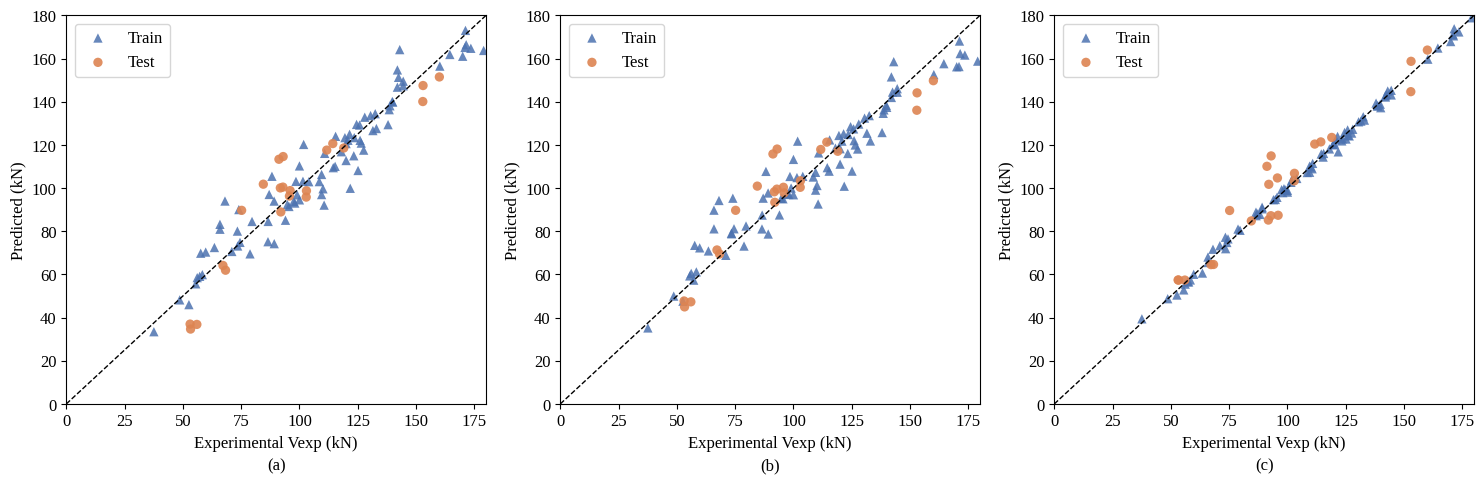

In [13]:
# Figure 5 — Predicted vs. Experimental shear capacity
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (name, letter) in zip(axes, [("Linear", "(a)"), ("Ridge", "(b)"), ("XGBoost", "(c)")]):
    ax.scatter(y[train_mask], preds_train[name], marker='^', color='#4C72B0',
               alpha=0.85, edgecolor='none', s=45, label='Train')
    ax.scatter(y[test_mask], b1_preds[name], marker='o', color='#DD8452',
               alpha=0.9, edgecolor='none', s=45, label='Test')
    lims = [0, 180]
    ax.plot(lims, lims, 'k--', linewidth=1)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('Experimental Vexp (kN)')
    ax.set_ylabel('Predicted (kN)')
    ax.legend(loc='upper left', frameon=True)
    ax.text(0.5, -0.17, letter, transform=ax.transAxes, ha='center')
plt.tight_layout()
plt.show()


In [14]:
# Table B1 — per-specimen predictions & % error (reference split)
table_b1 = df[['a_d','b','rho','fy','fc','ff','vf','vexp']].copy()
table_b1['Group'] = np.where(test_mask, 'Test', 'Train')
for name in ["Linear", "Ridge", "XGBoost"]:
    table_b1[f'{name}_pred'] = np.nan
    table_b1.loc[train_mask, f'{name}_pred'] = preds_train[name]
    table_b1.loc[test_mask,  f'{name}_pred'] = b1_preds[name]
    table_b1[f'{name}_err_%'] = 100*(table_b1[f'{name}_pred'] - table_b1['vexp'])/table_b1['vexp']
table_b1.round(2).head(10)


,a_d,b,rho,fy,fc,ff,vf,vexp,Group,Linear_pred,Linear_err_%,Ridge_pred,Ridge_err_%,XGBoost_pred,XGBoost_err_%
0,1.04,152.0,0.70,558,43.34,1100,0.7,84.5,Test,101.80,20.48,100.91,19.42,84.79,0.34
1,1.05,152.0,0.71,558,42.61,1100,0.7,92.9,Test,100.46,8.14,99.52,7.12,87.20,-6.14
2,1.02,151.0,0.70,558,41.63,1100,0.7,91.8,Test,100.07,9.01,98.29,7.07,85.19,-7.20
3,1.05,152.0,0.71,558,41.39,1100,0.7,96.0,Test,98.84,2.96,97.76,1.83,87.40,-8.95
4,1.07,156.0,0.69,558,32.48,1100,0.7,75.2,Test,89.69,19.27,89.71,19.29,89.61,19.17
5,0.43,153.0,0.45,495,38.31,1100,0.7,125.8,Train,129.20,2.70,127.43,1.29,126.95,0.91
6,0.72,151.0,0.45,495,45.12,1100,0.7,88.2,Train,105.46,19.57,107.73,22.15,87.80,-0.45
7,0.96,153.0,0.44,495,45.12,1100,0.7,65.9,Train,83.20,26.26,89.77,36.22,65.51,-0.59
8,0.43,154.0,0.70,558,41.63,1100,0.7,171.0,Train,165.16,-3.42,156.30,-8.60,171.09,0.05
9,0.55,153.0,1.02,491,46.17,1100,0.7,179.0,Train,163.76,-8.51,158.81,-11.28,178.89,-0.06


In [15]:
# Max absolute % error & residual std per model (paper text, end of Section 3.2)
for name in ["Linear", "Ridge", "XGBoost"]:
    err = table_b1[f'{name}_err_%']
    print(f"{name:10s} max|err|={err.abs().max():.1f}%   std={err.std():.2f}%   "
          f"within +-5% = {100*(err.abs()<=5).mean():.1f}%")
print("\nPaper: Linear max=38.1% std=11.45 | Ridge max=38.5% std=10.79 | "
      "XGBoost max=23.6%, within +-5% for 85.2% of dataset")


Linear     max|err|=38.1%   std=11.45%   within +-5% = 50.0%
Ridge      max|err|=38.5%   std=10.79%   within +-5% = 45.4%
XGBoost    max|err|=23.6%   std=4.60%   within +-5% = 85.2%

Paper: Linear max=38.1% std=11.45 | Ridge max=38.5% std=10.79 | XGBoost max=23.6%, within +-5% for 85.2% of dataset


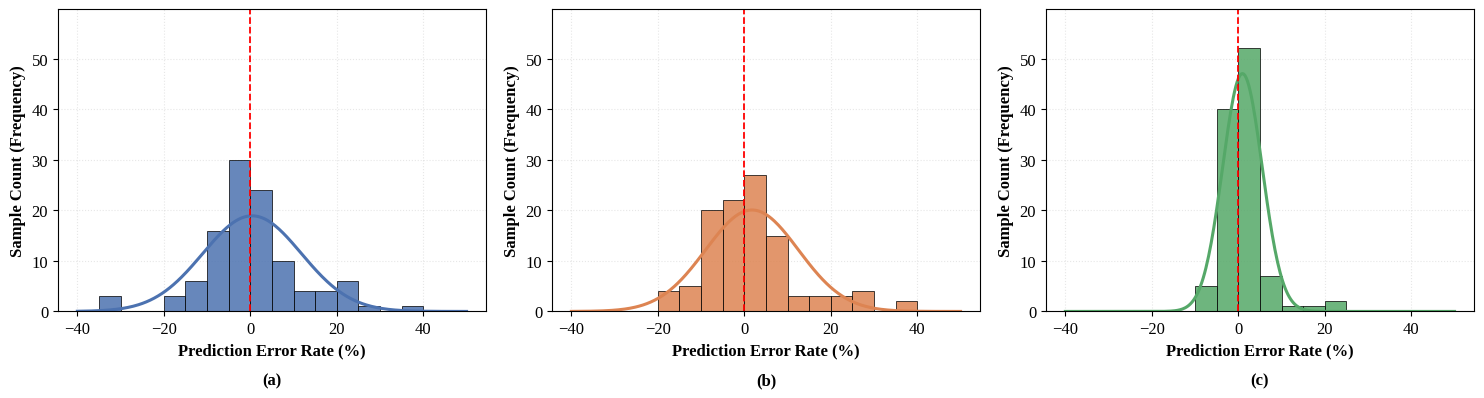

In [16]:
# Figure 6 — Prediction error rate histograms + fitted normal curves
from scipy.stats import norm
colors = {'Linear': '#4C72B0', 'Ridge': '#DD8452', 'XGBoost': '#55A868'}
bins = np.arange(-40, 51, 5)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
all_counts = [np.histogram(table_b1[f'{n}_err_%'].values, bins=bins)[0] for n in ['Linear','Ridge','XGBoost']]
shared_ylim = max(c.max() for c in all_counts) * 1.15
for ax, (name, letter) in zip(axes, [("Linear", "(a)"), ("Ridge", "(b)"), ("XGBoost", "(c)")]):
    e = table_b1[f'{name}_err_%'].values
    ax.hist(e, bins=bins, color=colors[name], edgecolor='black', linewidth=0.6, alpha=0.85)
    mu, sigma = e.mean(), e.std()
    xs = np.linspace(-40, 50, 300)
    bin_width = bins[1] - bins[0]
    ys = norm.pdf(xs, mu, sigma) * len(e) * bin_width
    ax.plot(xs, ys, color=colors[name], linewidth=2.2)
    ax.axvline(0, color='red', linestyle='--', linewidth=1.3)
    ax.set_xlabel('Prediction Error Rate (%)', fontweight='bold')
    ax.set_ylabel('Sample Count (Frequency)', fontweight='bold')
    ax.set_ylim(0, shared_ylim)
    ax.grid(True, alpha=0.3, linestyle=':')
    ax.set_axisbelow(True)
    ax.text(0.5, -0.24, letter, transform=ax.transAxes, ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


## 11) TABLE 8 — Exhaustive source-study partition sensitivity (fully nested)

For **each** of the 27 admissible source-study partitions (test share 15-35%), hyperparameters are re-selected using `inner_tune` on **only that partition's training studies** — so different partitions may select different Ridge alphas and XGBoost configurations. This is the slowest cell in the notebook (roughly 8-15 minutes); progress is printed per partition.


In [17]:
combos27 = [c for r in range(1, len(group_sizes)) for c in itertools.combinations(range(len(group_sizes)), r)
            if 15 <= 100*sum(group_sizes[i] for i in c)/n_total <= 35]
print(f"Total admissible partitions (15-35% test share): {len(combos27)} (paper: 27)")

exhaustive = {name: [] for name in ["Linear", "Ridge", "XGBoost"]}
partition_params = []
import time
t_start = time.time()
for i, combo in enumerate(combos27):
    te_mask = np.isin(groups, combo)
    tr_mask = ~te_mask
    p_alpha, p_xgb_base = inner_tune(X[tr_mask], y[tr_mask], groups[tr_mask])
    p_xgb = dict(p_xgb_base, gamma=0.3, objective='reg:squarederror', random_state=42, verbosity=0)
    partition_params.append(dict(combo=list(combo), alpha=p_alpha, xgb_params=p_xgb_base))

    m_lin = LinearRegression().fit(X[tr_mask], y[tr_mask])
    p_lin = m_lin.predict(X[te_mask])
    sc = StandardScaler().fit(X[tr_mask])
    m_ridge = Ridge(alpha=p_alpha).fit(sc.transform(X[tr_mask]), y[tr_mask])
    p_ridge = m_ridge.predict(sc.transform(X[te_mask]))
    m_xgb = XGBRegressor(**p_xgb).fit(X[tr_mask], y[tr_mask])
    p_xgb_pred = m_xgb.predict(X[te_mask])

    for name, p in [('Linear', p_lin), ('Ridge', p_ridge), ('XGBoost', p_xgb_pred)]:
        exhaustive[name].append((r2_score(y[te_mask], p), mean_absolute_error(y[te_mask], p)))

    elapsed = time.time() - t_start
    print(f"  [{i+1}/{len(combos27)}] combo={combo}  alpha={p_alpha}  "
          f"xgb(lr={p_xgb_base['learning_rate']}, n_est={p_xgb_base['n_estimators']})  "
          f"({elapsed:.0f}s elapsed)")
print("\nDone.")


Total admissible partitions (15-35% test share): 27 (paper: 27)
  [1/27] combo=(3,)  alpha=5  xgb(lr=0.1, n_est=600)  (97s elapsed)
  [2/27] combo=(4,)  alpha=5  xgb(lr=0.1, n_est=600)  (193s elapsed)
  [3/27] combo=(5,)  alpha=10  xgb(lr=0.05, n_est=600)  (283s elapsed)
  [4/27] combo=(6,)  alpha=0.001  xgb(lr=0.1, n_est=600)  (375s elapsed)
  [5/27] combo=(0, 3)  alpha=5  xgb(lr=0.1, n_est=400)  (469s elapsed)
  [6/27] combo=(0, 4)  alpha=1  xgb(lr=0.1, n_est=200)  (557s elapsed)
  [7/27] combo=(0, 5)  alpha=5  xgb(lr=0.05, n_est=600)  (645s elapsed)
  [8/27] combo=(0, 6)  alpha=0.001  xgb(lr=0.03, n_est=600)  (747s elapsed)
  [9/27] combo=(1, 3)  alpha=5  xgb(lr=0.1, n_est=600)  (856s elapsed)
  [10/27] combo=(1, 4)  alpha=5  xgb(lr=0.1, n_est=200)  (965s elapsed)
  [11/27] combo=(1, 5)  alpha=5  xgb(lr=0.05, n_est=200)  (1082s elapsed)
  [12/27] combo=(1, 6)  alpha=0.001  xgb(lr=0.1, n_est=600)  (1163s elapsed)
  [13/27] combo=(2, 3)  alpha=10  xgb(lr=0.05, n_est=200)  (1247s elaps

In [18]:
# TABLE 8 summary statistics
table8_rows = []
for name in ["Linear", "Ridge", "XGBoost"]:
    r2s = np.array([r for r, _ in exhaustive[name]])
    maes = np.array([m for _, m in exhaustive[name]])
    q1, med, q3 = np.percentile(r2s, [25, 50, 75])
    table8_rows.append([name, r2s.mean(), med, f"{q1:.3f}\u2013{q3:.3f}", f"{r2s.min():.2f}/{r2s.max():.2f}",
                         100*np.mean(r2s > 0), 100*np.mean(r2s > 0.7), np.median(maes)])
table8 = pd.DataFrame(table8_rows, columns=["Model", "Mean R2", "Median R2", "IQR (Q1-Q3)",
                                             "Min/Max", "R2>0 (%)", "R2>0.7 (%)", "Median MAE"]).round(3)
print("Paper: Linear mean=0.547 median=0.860 IQR=0.570-0.883 pos%=85.2 gt07%=70.4 medMAE=10.02")
print("       Ridge  mean=0.485 median=0.845 IQR=0.293-0.868 pos%=85.2 gt07%=66.7 medMAE=10.02")
print("       XGBoost mean=0.361 median=0.585 IQR=0.173-0.752 pos%=81.5 gt07%=37.0 medMAE=14.43")
table8


Paper: Linear mean=0.547 median=0.860 IQR=0.570-0.883 pos%=85.2 gt07%=70.4 medMAE=10.02
       Ridge  mean=0.485 median=0.845 IQR=0.293-0.868 pos%=85.2 gt07%=66.7 medMAE=10.02
       XGBoost mean=0.361 median=0.585 IQR=0.173-0.752 pos%=81.5 gt07%=37.0 medMAE=14.43


,Model,Mean R2,Median R2,IQR (Q1-Q3),Min/Max,R2>0 (%),R2>0.7 (%),Median MAE
0,Linear,0.547,0.860,0.570–0.883,-1.72/0.93,85.185,70.370,10.022
1,Ridge,0.485,0.845,0.293–0.868,-1.72/0.91,85.185,66.667,10.020
2,XGBoost,0.361,0.585,0.173–0.752,-1.78/0.92,81.481,37.037,14.435


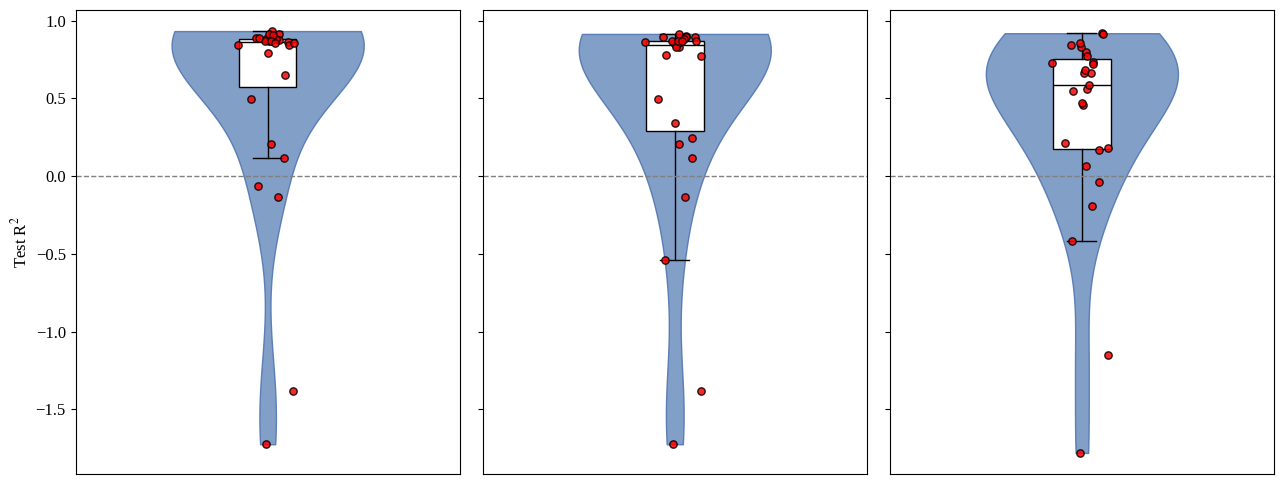

In [19]:
# Figure 7 — distribution of test R2 across the 27 nested exhaustive splits
fig, axes = plt.subplots(1, 3, figsize=(13, 5), sharey=True)
for ax, name in zip(axes, ["Linear", "Ridge", "XGBoost"]):
    r2s = np.array([r for r, _ in exhaustive[name]])
    parts = ax.violinplot(r2s, showmeans=False, showmedians=False, showextrema=False)
    for pc in parts['bodies']:
        pc.set_facecolor('#6C8EBF'); pc.set_edgecolor('#4C72B0'); pc.set_alpha(0.85)
    bp = ax.boxplot(r2s, widths=0.15, patch_artist=True, showfliers=False,
                     medianprops=dict(color='black'))
    for box in bp['boxes']:
        box.set_facecolor('white'); box.set_edgecolor('black')
    x_jitter = np.random.RandomState(0).normal(1, 0.03, size=len(r2s))
    ax.scatter(x_jitter, r2s, color='red', edgecolor='black', s=28, zorder=3, alpha=0.85)
    ax.axhline(0, color='grey', linestyle='--', linewidth=1)
    ax.set_xticks([])
axes[0].set_ylabel('Test R$^2$')
plt.tight_layout()
plt.show()


In [20]:
# 12) TABLE 9 — Bootstrap analysis (1000 reps, out-of-bag, full dataset,
# independent of source-study grouping; uses the primary nested config from Table 3)
rng = np.random.RandomState(0)
n_boot = 1000
boot_r2 = {name: [] for name in ["Linear", "Ridge", "XGBoost"]}
idx_all = np.arange(n_total)
for b in range(n_boot):
    boot_idx = rng.choice(idx_all, size=n_total, replace=True)
    oob_idx = np.setdiff1d(idx_all, np.unique(boot_idx))
    if len(oob_idx) < 5:
        continue
    for name in ["Linear", "Ridge", "XGBoost"]:
        pred, _ = fit_predict(name, X[boot_idx], y[boot_idx], X[oob_idx])
        boot_r2[name].append(r2_score(y[oob_idx], pred))

table9_rows = []
for name in ["Linear", "Ridge", "XGBoost"]:
    arr = np.array(boot_r2[name])
    lo, hi = np.percentile(arr, [2.5, 97.5])
    table9_rows.append([name, arr.mean(), f"{lo:.3f}\u2013{hi:.3f}"])
table9 = pd.DataFrame(table9_rows, columns=["Model", "Mean R2", "95% CI"]).round(3)
print("Paper: Linear 0.891(0.819-0.936) | Ridge 0.889(0.814-0.936) | XGBoost 0.864(0.740-0.931)")
table9


Paper: Linear 0.891(0.819-0.936) | Ridge 0.889(0.814-0.936) | XGBoost 0.864(0.740-0.931)


,Model,Mean R2,95% CI
0,Linear,0.891,0.819–0.936
1,Ridge,0.889,0.814–0.936
2,XGBoost,0.864,0.740–0.931


In [21]:
# 13) TABLE 10 — Standardized regression coefficients (primary nested config, full dataset)
sc_full = StandardScaler().fit(X)
Xs = sc_full.transform(X)
lin_full = LinearRegression().fit(Xs, y)
ridge_full = Ridge(alpha=RIDGE_ALPHA).fit(Xs, y)

table10 = pd.DataFrame({'Linear': lin_full.coef_, 'Ridge': ridge_full.coef_}, index=features).round(3)
print("Paper Linear: a/d=-20.87 rho=20.11 Vf=13.24 fc=8.36 ff=-12.05 fy=6.29 b=1.53 (unchanged)")
print("Paper Ridge : a/d=-19.01 rho=18.07 Vf=12.84 fc=8.83 ff=-10.14 fy=4.36 b=2.02")
table10


Paper Linear: a/d=-20.87 rho=20.11 Vf=13.24 fc=8.36 ff=-12.05 fy=6.29 b=1.53 (unchanged)
Paper Ridge : a/d=-19.01 rho=18.07 Vf=12.84 fc=8.83 ff=-10.14 fy=4.36 b=2.02


,Linear,Ridge
a_d,-20.871,-19.010
b,1.527,2.023
rho,20.106,18.070
fy,6.287,4.359
fc,8.358,8.830
ff,-12.046,-10.142
vf,13.236,12.837


In [22]:
# 14) FIGURES 8-11 — SHAP explainability (primary nested config, full dataset)
xgb_full = XGBRegressor(**XGB_PARAMS).fit(X, y)

masker_s = shap.maskers.Independent(Xs, max_samples=Xs.shape[0])
shap_lin = shap.LinearExplainer(lin_full, masker_s).shap_values(Xs)
shap_ridge = shap.LinearExplainer(ridge_full, masker_s).shap_values(Xs)
shap_xgb = shap.TreeExplainer(xgb_full, feature_perturbation='tree_path_dependent').shap_values(X)

shap_summary = pd.DataFrame({
    'Linear': np.abs(shap_lin).mean(axis=0),
    'Ridge': np.abs(shap_ridge).mean(axis=0),
    'XGBoost': np.abs(shap_xgb).mean(axis=0),
}, index=features).round(3)

print("Reproduced (mean |SHAP|), sorted per model:")
for col in ["Linear", "Ridge", "XGBoost"]:
    ordered = shap_summary[col].sort_values(ascending=False)
    ranking_str = " > ".join(f"{feat} ({val:.2f})" for feat, val in ordered.items())
    print(f"  {col:8s}: {ranking_str}")
print("\nPaper XGBoost: a/d(16.27) > rho(14.28) > Vf(7.67) > fc(5.80) > b(4.61) > fy(0.65) > ff(0.00)")
print("Note: ff reaches exactly zero mean |SHAP| under the nested-tuned XGBoost config—")
print("      it is not used in any split of the fitted model.")


Reproduced (mean |SHAP|), sorted per model:
  Linear  : a_d (17.44) > rho (16.76) > vf (11.19) > ff (10.02) > fc (6.71) > fy (5.56) > b (1.26)
  Ridge   : a_d (15.89) > rho (15.07) > vf (10.85) > ff (8.43) > fc (7.08) > fy (3.85) > b (1.68)
  XGBoost : a_d (16.27) > rho (14.28) > vf (7.67) > fc (5.80) > b (4.61) > fy (0.65) > ff (0.00)

Paper XGBoost: a/d(16.27) > rho(14.28) > Vf(7.67) > fc(5.80) > b(4.61) > fy(0.65) > ff(0.00)
Note: ff reaches exactly zero mean |SHAP| under the nested-tuned XGBoost config—
      it is not used in any split of the fitted model.


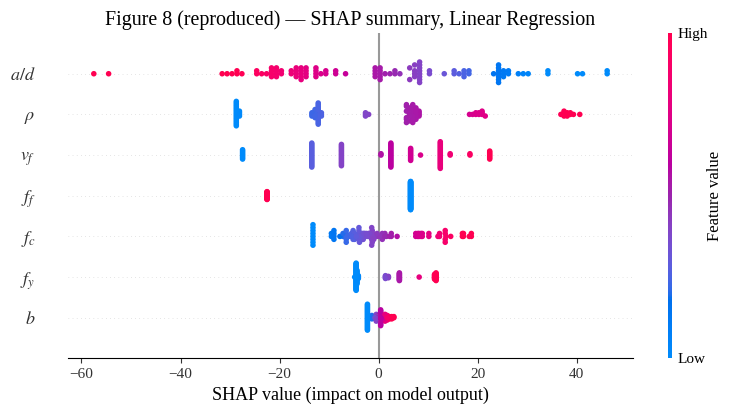

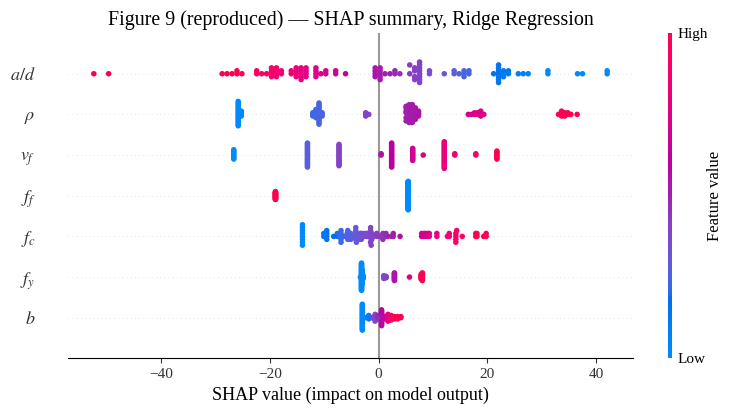

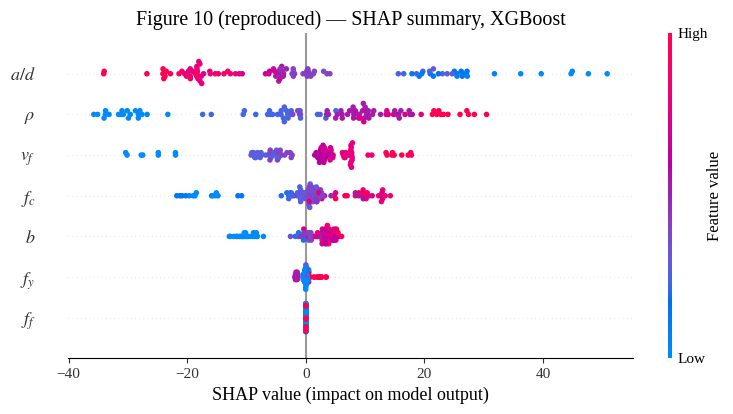

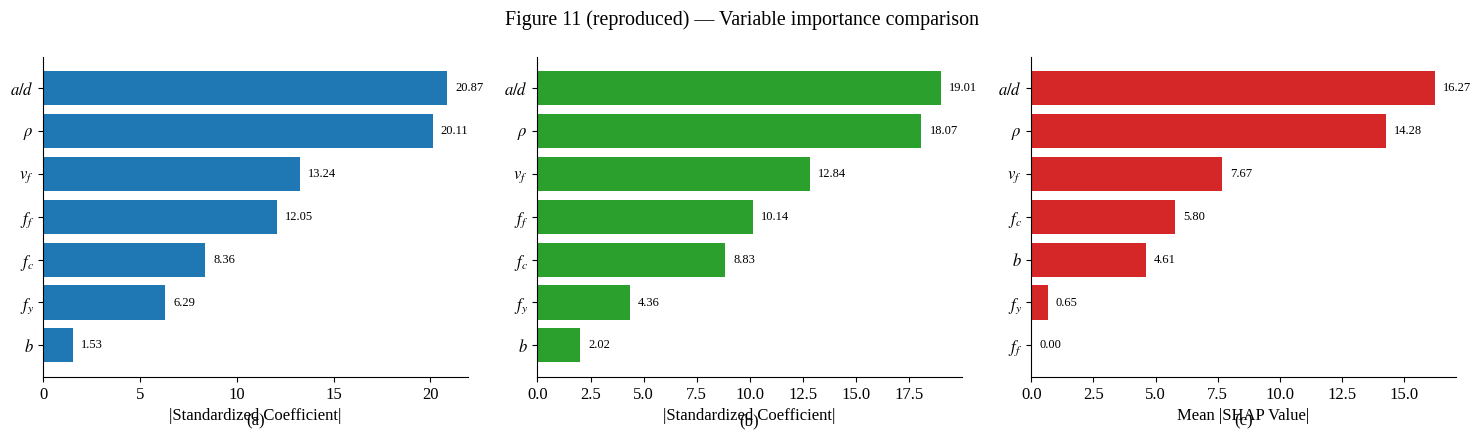

In [23]:
# Figures 8-10 — SHAP beeswarm summary plots (using shap's own default styling)
pretty_names = [r'$a/d$', r'$b$', r'$\rho$', r'$f_y$', r'$f_c$', r'$f_f$', r'$v_f$']

for shap_vals, feat_data, fig_title in [
    (shap_lin, Xs, 'Figure 8 (reproduced) — SHAP summary, Linear Regression'),
    (shap_ridge, Xs, 'Figure 9 (reproduced) — SHAP summary, Ridge Regression'),
    (shap_xgb, X, 'Figure 10 (reproduced) — SHAP summary, XGBoost'),
]:
    plt.figure()
    shap.summary_plot(shap_vals, feat_data, feature_names=pretty_names, show=False)
    plt.title(fig_title)
    plt.tight_layout()
    plt.show()

# Figure 11 — standardized coefficients (a, b) + SHAP (c) side by side
pretty = {'a_d': r'$a/d$', 'b': r'$b$', 'rho': r'$\rho$', 'ff': r'$f_f$',
          'fy': r'$f_y$', 'fc': r'$f_c$', 'vf': r'$v_f$'}
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
panels = [
    (table10['Linear'].abs(), 'tab:blue', '|Standardized Coefficient|', '(a)'),
    (table10['Ridge'].abs(), 'tab:green', '|Standardized Coefficient|', '(b)'),
    (shap_summary['XGBoost'], 'tab:red', 'Mean |SHAP Value|', '(c)'),
]
for ax, (series, color, xlabel, letter) in zip(axes, panels):
    s = series.sort_values()
    bars = ax.barh([pretty[f] for f in s.index], s.values, color=color)
    for b, v in zip(bars, s.values):
        ax.text(v + s.max()*0.02, b.get_y() + b.get_height()/2, f'{v:.2f}', va='center', fontsize=9)
    ax.set_xlabel(xlabel)
    ax.text(0.5, -0.15, letter, transform=ax.transAxes, ha='center')
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
plt.suptitle('Figure 11 (reproduced) — Variable importance comparison')
plt.tight_layout()
plt.show()


## 15) Comparison with a published empirical equation

Fattuhi's (1994) equation requires the absolute corbel height/effective depth (h, d) and the splitting tensile strength of concrete (ft) — none are recorded separately in this database (only a/d is available), so it cannot be evaluated here. A strut-and-tie / ACI 318 shear-friction check would require nodal-zone and bearing-plate geometry not present in the compiled parameters, so it is not attempted either. The Kurtoğlu et al. (2017) symbolic-regression equation uses only variables available here except ft, which we estimate from fc via a standard relationship. **This reconstruction should be verified against the original paper before being treated as final.**


In [24]:
# Kurtoglu et al. (2017): Vp = c*(k1 + k2*rho^k3*ff^k4*fc^k5*exp(Vf*k6)*ln(ft*fy^k7*(a/d)^k8))
# ft (splitting tensile strength of concrete) is not reported by any source study; estimated via
# ft = 0.56*sqrt(fc) (MPa), a standard splitting-tensile-strength relationship.
# rho and Vf are used as FRACTIONS (not %) to match the original equation's scale.
k1, k2, k3, k4, k5, k6, k7, k8 = 10.07, 20.6, 0.541, 0.406, 0.22, 3.27, 0.0338, 0.807
c_fiber = 1.0  # steel fibers

ft_est = 0.56 * np.sqrt(df['fc'])
rho_frac = df['rho'] / 100
vf_frac = df['vf'] / 100
inner_log = ft_est * (df['fy']**k7) * (df['a_d']**k8)
kurtoglu_pred = c_fiber * (k1 + k2 * (rho_frac**k3) * (df['ff']**k4) * (df['fc']**k5)
                            * np.exp(vf_frac*k6) * np.log(inner_log))
df['kurtoglu_pred'] = kurtoglu_pred

# Evaluate on the SAME predefined hold-out test set as the ML models (Table 7)
yt, yp = y[test_mask], kurtoglu_pred.values[test_mask]
print("Kurtoglu eq. on predefined hold-out TEST set (n=22):")
print(f"  R2={r2_score(yt,yp):.3f}  RMSE={np.sqrt(mean_squared_error(yt,yp)):.2f}  "
      f"MAE={mean_absolute_error(yt,yp):.2f}  MAPE={mape(yt,yp):.2f}%")
print("Paper: R2=-0.43 RMSE=35.38 MAE=24.84 MAPE=22.94%")

# Evaluate on the SAME 27 exhaustive partitions as Table 8
kurt_r2s, kurt_maes = [], []
for combo in combos27:
    te_mask = np.isin(groups, combo)
    yt2, yp2 = y[te_mask], kurtoglu_pred.values[te_mask]
    kurt_r2s.append(r2_score(yt2, yp2)); kurt_maes.append(mean_absolute_error(yt2, yp2))
kurt_r2s = np.array(kurt_r2s); kurt_maes = np.array(kurt_maes)
print(f"\nKurtoglu eq. across 27 exhaustive partitions:")
print(f"  mean={kurt_r2s.mean():.3f} median={np.median(kurt_r2s):.3f} "
      f"pos%={100*np.mean(kurt_r2s>0):.1f} gt07%={100*np.mean(kurt_r2s>0.7):.1f} "
      f"medMAE={np.median(kurt_maes):.2f}")
print("Paper: mean=-1.23 median=-0.82 pos%=7.4 gt07%=0.0 medMAE=34.80")


Kurtoglu eq. on predefined hold-out TEST set (n=22):
  R2=-0.428  RMSE=35.38  MAE=24.84  MAPE=22.94%
Paper: R2=-0.43 RMSE=35.38 MAE=24.84 MAPE=22.94%

Kurtoglu eq. across 27 exhaustive partitions:
  mean=-1.233 median=-0.816 pos%=7.4 gt07%=0.0 medMAE=34.80
Paper: mean=-1.23 median=-0.82 pos%=7.4 gt07%=0.0 medMAE=34.80


## 16) Residual analysis and sources of negative R²


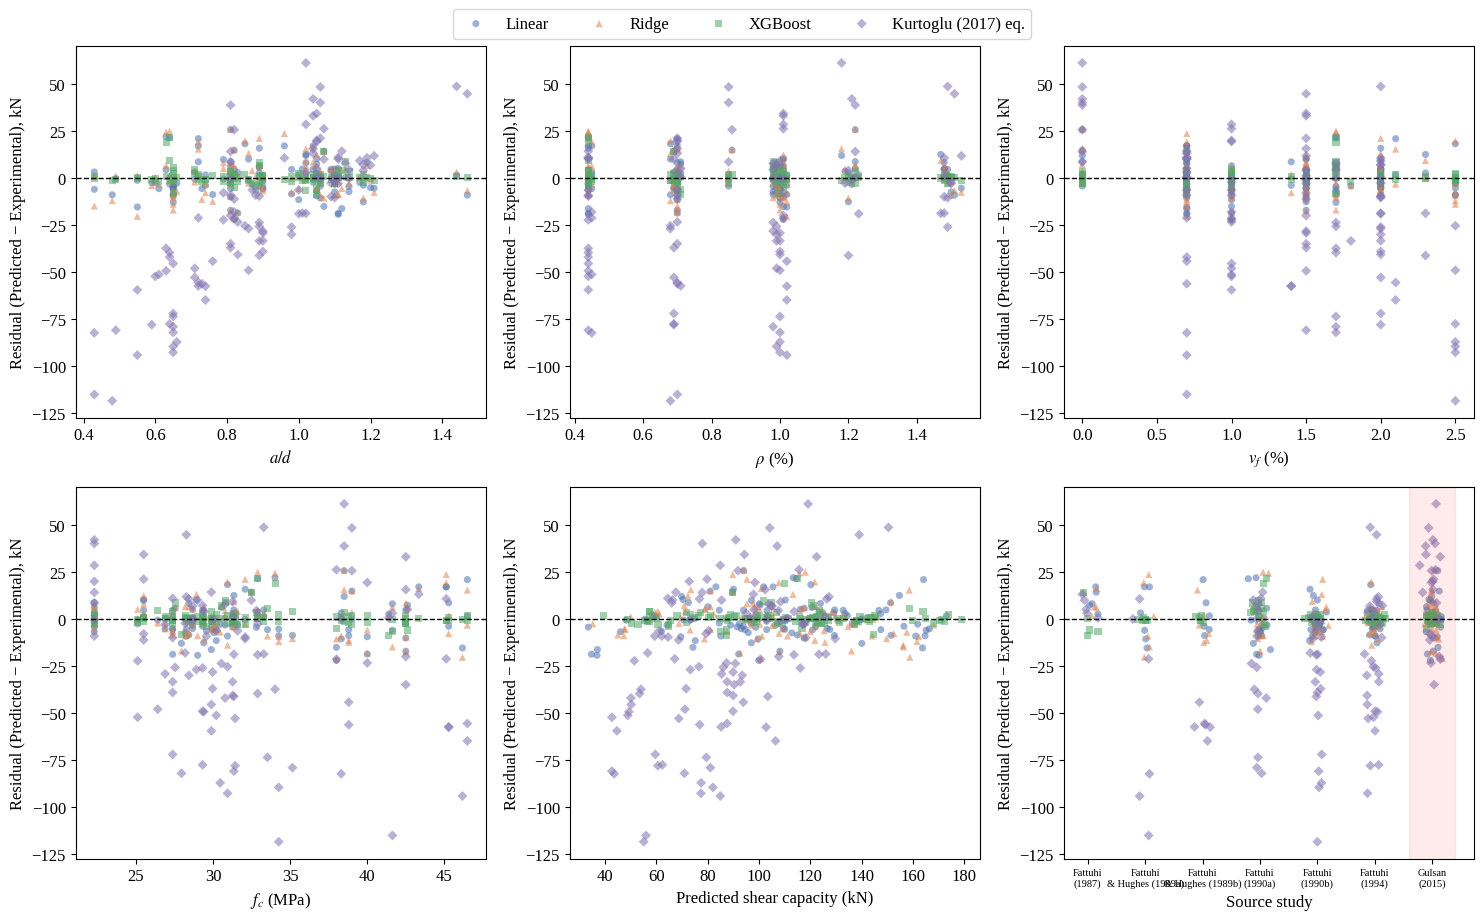

In [25]:
# Figure 12 -- Residuals (Predicted - Experimental) vs a/d, rho, Vf, fc, predicted value, and source study
table_b1['kurtoglu_pred'] = kurtoglu_pred.values
table_b1['kurtoglu_resid'] = table_b1['kurtoglu_pred'] - table_b1['vexp']
for name in ["Linear", "Ridge", "XGBoost"]:
    table_b1[f'{name}_resid'] = table_b1[f'{name}_pred'] - table_b1['vexp']
table_b1['study_idx'] = groups

colors = {'Linear': '#4C72B0', 'Ridge': '#DD8452', 'XGBoost': '#55A868', 'Kurtoglu (2017) eq.': '#8172B2'}
markers = {'Linear': 'o', 'Ridge': '^', 'XGBoost': 's', 'Kurtoglu (2017) eq.': 'D'}
model_cols = {'Linear': 'Linear_resid', 'Ridge': 'Ridge_resid', 'XGBoost': 'XGBoost_resid',
              'Kurtoglu (2017) eq.': 'kurtoglu_resid'}

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
panels = [(axes[0,0], 'a_d', r'$a/d$'), (axes[0,1], 'rho', r'$\rho$ (%)'),
          (axes[0,2], 'vf', r'$v_f$ (%)'), (axes[1,0], 'fc', r'$f_c$ (MPa)')]
for ax, col, xlabel in panels:
    for name, rcol in model_cols.items():
        ax.scatter(table_b1[col], table_b1[rcol], color=colors[name], marker=markers[name],
                   alpha=0.55, s=26, label=name, edgecolor='none')
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Residual (Predicted − Experimental), kN')

ax = axes[1,1]
for name, rcol in model_cols.items():
    xcol = table_b1['kurtoglu_pred'] if name == 'Kurtoglu (2017) eq.' else table_b1[f'{name}_pred']
    ax.scatter(xcol, table_b1[rcol], color=colors[name], marker=markers[name],
               alpha=0.55, s=26, label=name, edgecolor='none')
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Predicted shear capacity (kN)')
ax.set_ylabel('Residual (Predicted − Experimental), kN')

ax = axes[1,2]
rng = np.random.RandomState(0)
study_labels = [n.replace(' ', '\n', 1) for n in group_names]
for name, rcol in model_cols.items():
    jitter = rng.normal(0, 0.08, size=len(table_b1))
    ax.scatter(table_b1['study_idx'] + jitter, table_b1[rcol], color=colors[name], marker=markers[name],
               alpha=0.55, s=26, label=name, edgecolor='none')
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_xticks(range(7)); ax.set_xticklabels(study_labels, fontsize=7.5)
ax.set_xlabel('Source study'); ax.set_ylabel('Residual (Predicted − Experimental), kN')
ax.axvspan(5.6, 6.4, color='red', alpha=0.08)  # Gulsan (2015)

handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4, bbox_to_anchor=(0.5, 1.03), frameon=True)
plt.tight_layout()
plt.show()


In [26]:
# Identify which of the 27 exhaustive partitions gave NEGATIVE R2, and which source studies
# were held out in each -- this is a fully data-driven check, not an assumption.
print("=== Partitions yielding NEGATIVE R2 (test-group studies held out) ===\n")
for name in ["Linear", "Ridge", "XGBoost"]:
    print(f"--- {name} ---")
    for i, (r2, mae) in enumerate(exhaustive[name]):
        if r2 < 0:
            combo = partition_params[i]['combo']
            studies = [group_names[g] for g in combo]
            print(f"  R2={r2:.3f} MAE={mae:.2f}  held-out test studies: {studies}")
    print()
print(">>> Expected: Gulsan (2015) appears in every negative-R2 partition for all three models.")
print(">>> Gulsan (2015) is the only source study with Vf=0% specimens and the only study using")
print(">>> ff=1200 MPa (vs. 1100 MPa elsewhere) -- a genuine parameter-region gap, not an artifact.")


=== Partitions yielding NEGATIVE R2 (test-group studies held out) ===

--- Linear ---
  R2=-1.384 MAE=33.64  held-out test studies: ['Gulsan (2015)']
  R2=-1.725 MAE=32.70  held-out test studies: ['Fattuhi (1987)', 'Gulsan (2015)']
  R2=-0.063 MAE=27.75  held-out test studies: ['Fattuhi (1987)', 'Fattuhi & Hughes (1989a)', 'Gulsan (2015)']
  R2=-0.136 MAE=30.17  held-out test studies: ['Fattuhi (1987)', 'Fattuhi & Hughes (1989b)', 'Gulsan (2015)']

--- Ridge ---
  R2=-1.384 MAE=33.64  held-out test studies: ['Gulsan (2015)']
  R2=-1.725 MAE=32.70  held-out test studies: ['Fattuhi (1987)', 'Gulsan (2015)']
  R2=-0.541 MAE=36.14  held-out test studies: ['Fattuhi (1987)', 'Fattuhi & Hughes (1989a)', 'Gulsan (2015)']
  R2=-0.136 MAE=30.17  held-out test studies: ['Fattuhi (1987)', 'Fattuhi & Hughes (1989b)', 'Gulsan (2015)']

--- XGBoost ---
  R2=-1.151 MAE=31.54  held-out test studies: ['Gulsan (2015)']
  R2=-1.780 MAE=33.21  held-out test studies: ['Fattuhi (1987)', 'Gulsan (2015)']
  R2

## 17) Table 2 -- per-source-study parameter ranges


In [27]:
table2 = df.copy()
table2['study'] = [group_names[g] for g in groups]
cols = ['a_d','b','rho','fy','fc','ff','vf']
for name in group_names:
    sub = table2[table2['study']==name]
    print(f"=== {name} (n={len(sub)}) ===")
    for c in cols:
        print(f"  {c}: {sub[c].min():.2f} - {sub[c].max():.2f}")
    print()


=== Fattuhi (1987) (n=5) ===
  a_d: 1.02 - 1.07
  b: 151.00 - 156.00
  rho: 0.69 - 0.71
  fy: 558.00 - 558.00
  fc: 32.48 - 43.34
  ff: 1100.00 - 1100.00
  vf: 0.70 - 0.70

=== Fattuhi & Hughes (1989a) (n=6) ===
  a_d: 0.43 - 1.06
  b: 151.00 - 154.00
  rho: 0.44 - 1.02
  fy: 491.00 - 558.00
  fc: 38.31 - 46.17
  ff: 1100.00 - 1100.00
  vf: 0.70 - 0.70

=== Fattuhi & Hughes (1989b) (n=6) ===
  a_d: 0.72 - 0.76
  b: 151.00 - 152.00
  rho: 0.70 - 1.02
  fy: 491.00 - 558.00
  fc: 38.80 - 46.49
  ff: 1100.00 - 1100.00
  vf: 0.70 - 2.10

=== Fattuhi (1990a) (n=17) ===
  a_d: 0.63 - 1.14
  b: 152.50 - 155.50
  rho: 0.44 - 1.00
  fy: 449.00 - 452.00
  fc: 26.41 - 35.15
  ff: 1100.00 - 1100.00
  vf: 0.70 - 1.70

=== Fattuhi (1990b) (n=22) ===
  a_d: 0.48 - 1.10
  b: 151.50 - 156.00
  rho: 0.44 - 1.50
  fy: 451.00 - 454.00
  fc: 27.38 - 34.26
  ff: 1100.00 - 1100.00
  vf: 1.00 - 2.50

=== Fattuhi (1994) (n=28) ===
  a_d: 0.55 - 1.47
  b: 150.40 - 154.50
  rho: 0.44 - 1.53
  fy: 451.00 - 451.00


## 18) ff correlation / source-study confounding analysis

Investigates why fiber tensile strength (ff) shows a negative correlation with shear capacity despite no plausible physical mechanism for higher fiber strength to reduce capacity.


In [28]:
from sklearn.linear_model import LinearRegression as _LR

print("corr(ff, vf):", df['ff'].corr(df['vf']))
print("corr(ff, vexp):", df['ff'].corr(df['vexp']))
print("corr(ff, fy):", df['ff'].corr(df['fy']))
print("corr(vf, vexp):", df['vf'].corr(df['vexp']))
print("corr(fy, vexp):", df['fy'].corr(df['vexp']))

def partial_corr(df, x, y, controls):
    Xc = df[controls].values
    rx = df[x].values - _LR().fit(Xc, df[x].values).predict(Xc)
    ry = df[y].values - _LR().fit(Xc, df[y].values).predict(Xc)
    return np.corrcoef(rx, ry)[0, 1]

print("\nPartial corr(ff, Vexp | Vf, fy):", partial_corr(df, 'ff', 'vexp', ['vf','fy']))
print("Paper: -0.41")

print("\nff is a near-binary source-study indicator:")
print("Unique ff values:", df['ff'].unique())
print(df.groupby('ff')['vexp'].agg(['count','mean','std']))
print(df.groupby('ff')['vf'].agg(['mean','min','max']))
print("Paper: ff=1100 mean Vexp=115.6, ff=1200 (Gulsan) mean Vexp=75.9")


corr(ff, vf): -0.4379238164448565
corr(ff, vexp): -0.5017550521030906
corr(ff, fy): 0.669668299093999
corr(vf, vexp): 0.6251264361253086
corr(fy, vexp): -0.3274388773117402

Partial corr(ff, Vexp | Vf, fy): -0.4113668761876561
Paper: -0.41

ff is a near-binary source-study indicator:
Unique ff values: [1100 1200]
      count        mean        std
ff                                
1100     84  115.563095  29.710169
1200     24   75.865833  24.815445
          mean  min  max
ff                      
1100  1.532143  0.7  2.5
1200  0.833333  0.0  1.5
Paper: ff=1100 mean Vexp=115.6, ff=1200 (Gulsan) mean Vexp=75.9


## Methodological notes

1. **Nested tuning is the primary method throughout**, not a post-hoc sensitivity check: hyperparameters for Ridge and XGBoost are selected using only the training portion of each outer evaluation (the predefined hold-out, and independently for each of the 27 exhaustive partitions).
2. **Table 6** (standard 5-fold CV) and **Table 9** (bootstrap) use the single primary configuration derived from the predefined hold-out's inner search, since neither involves a source-study test set whose leakage into tuning is a concern in the same way as the group-based evaluations.
3. **Reproducibility**: Linear and Ridge results are exactly reproducible given the documented environment, seed, and dataset ordering. XGBoost results are reproducible to close numerical agreement but may show minor differences on different hardware or library versions, consistent with known gradient-boosting library behavior.
4. Random seeds: `KFold(random_state=42)` for Table 6; `GroupKFold` (deterministic, no seed) for all inner tuning; `XGBRegressor(random_state=42)` for all XGBoost fits; `RandomState(seed=0)` for the bootstrap (Table 9).
